In [66]:

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


In [67]:
def draw_adj(adj, ax=None, title=None):
    n = len(adj)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for u in range(n):
        for v in range(u+1, n):
            if adj[u, v]:
                G.add_edge(u, v)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, with_labels=True,
            node_color='#1D9E75', node_size=500,
            font_color='white', font_weight='bold',
            edge_color='#444', width=1.5)
    if title:
        ax.set_title(title, fontsize=10)
    return ax

In [87]:
class SubgraphChecker:
  def __init__(self, n):
    self.n = n
  
  def check(self, adj, u, v) -> bool:
    # called AFTER edge (u,v) has been added to adj
    # returns True if forbidden subgraph now exists
    raise NotImplementedError
  
class C4Checker(SubgraphChecker): #WARNING u = v is an issue 
  def check(self, adj, u, v) -> bool:
    assert u != v
    n = self.n
    for x in range(n):
        if not adj[u][x] or x == v: continue
        for y in range(n):
            if not adj[v][y] or y == u: continue
            if x != y and adj[x][y]:
                return True
    return False
  
class C6Checker(SubgraphChecker):
  def check(self, adj, u, v) -> bool:
    # fast filter
    row = adj[u].astype(np.int32)
    A = adj.astype(np.int32)
    a2 = row @ A
    a3 = a2  @ A
    a5 = a3  @ A @ A
    if not a5[v]:
        return False
    # confirm with path check
    return self._has_path_length(adj, u, v, 5)
  
  def _has_path_length(self, adj, u, v, length) -> bool:
    # DFS looking for simple path of exact length from u to v
    def dfs(node, target, remaining, visited):
      if remaining == 0:
        return node == target
      for w in range(self.n):
        if adj[node][w] and w not in visited:
          visited.add(w)
          if dfs(w, target, remaining - 1, visited):
            return True
          visited.remove(w)
      return False
    return dfs(u, v, length, {u})
  
class K23Checker(SubgraphChecker):
    def check(self, adj, u, v) -> bool:
        # called BEFORE adding edge (u,v)
        for candidate, other in [(u, v), (v, u)]:
            for w in range(self.n):
                if w == candidate or w == other: continue
                if adj[other][w] and (adj[candidate] & adj[w]).sum() >= 2:
                    return True
        return False

In [88]:
adj = np.zeros((6,6)).astype(bool)

def build_adj(n, edges):
    adj = np.zeros((n, n), dtype=bool)
    for u, v in edges:
        adj[u, v] = 1
        adj[v, u] = 1
    return adj
  
edge_list = [(0,1),(0,3),(1,3),(1,2),(2,4),(4,5)]
adj = build_adj(6,edge_list)

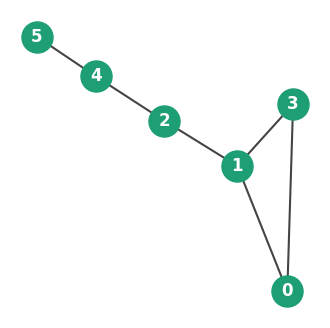

In [89]:
draw_adj(adj)
plt.show()

In [90]:
checkerC4 = C4Checker(6)
checkerC4.check(adj,3,4)

checkerC6 = C6Checker(6)
checkerC6.check(adj,1,4)

False

<Axes: >

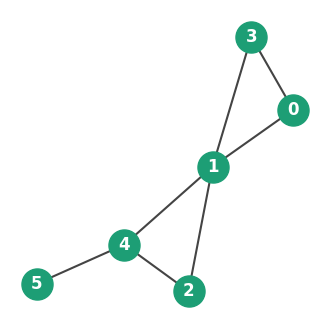

In [91]:
adj[1,4] = 1 
adj[4,1] = 1
draw_adj(adj)

<Axes: >

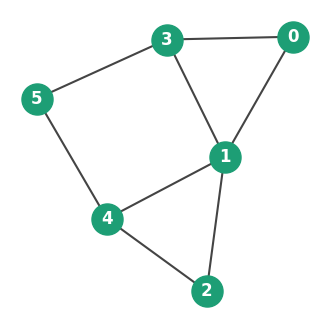

In [92]:
adj[5,3] = 1
adj[3,5] = 1
draw_adj(adj)

In [93]:
checker_k23 = K23Checker(6)
checker_k23.check(adj,2,5)

True

<Axes: >

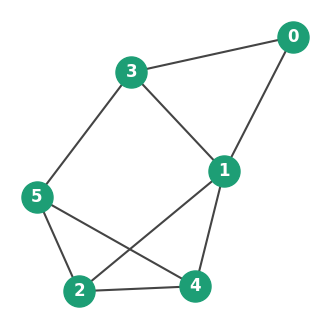

In [94]:
adj[5,2] = 1
adj[2,5] = 1
draw_adj(adj)

In [86]:
adj

array([[False,  True, False,  True, False, False],
       [ True, False,  True,  True,  True, False],
       [False,  True, False, False,  True,  True],
       [ True,  True, False, False, False,  True],
       [False, False,  True, False, False,  True],
       [False, False,  True,  True,  True, False]])